[INFO] Diretório de dados mapeado: C:\Projetos\TCC2\Resultados


,smape,mae,rmse,runtime_sec
model,,,,
xgboost,82.1356,15.5558,24.6508,34.2
gru,98.8635,15.2512,25.9941,5593.7
lstm,102.6089,24.6964,32.5395,7742.1


C:\Users\lucas\AppData\Local\Temp\ipykernel_15804\304549527.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df_latest.index, y=df_latest['runtime_sec'], palette="magma")


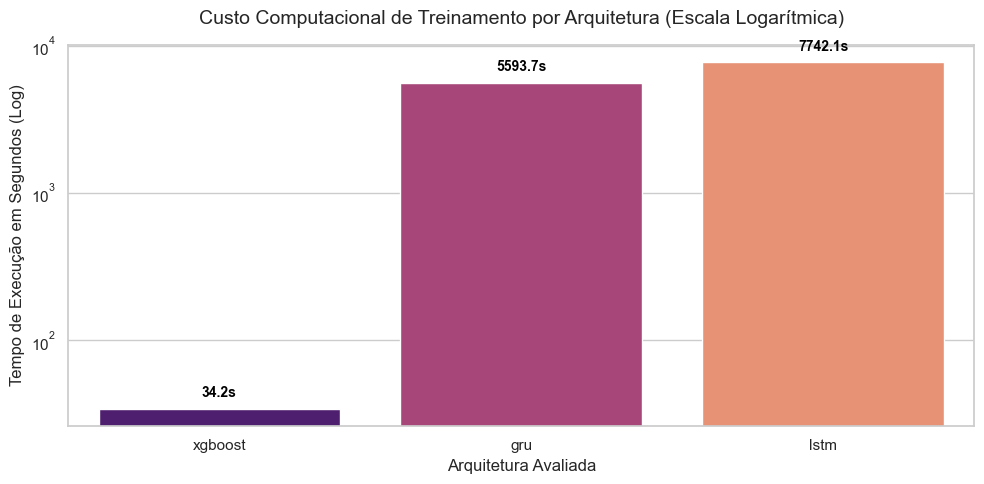

C:\Users\lucas\AppData\Local\Temp\ipykernel_15804\304549527.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df_wape.index, y=df_wape['WAPE (%)'], palette="viridis")


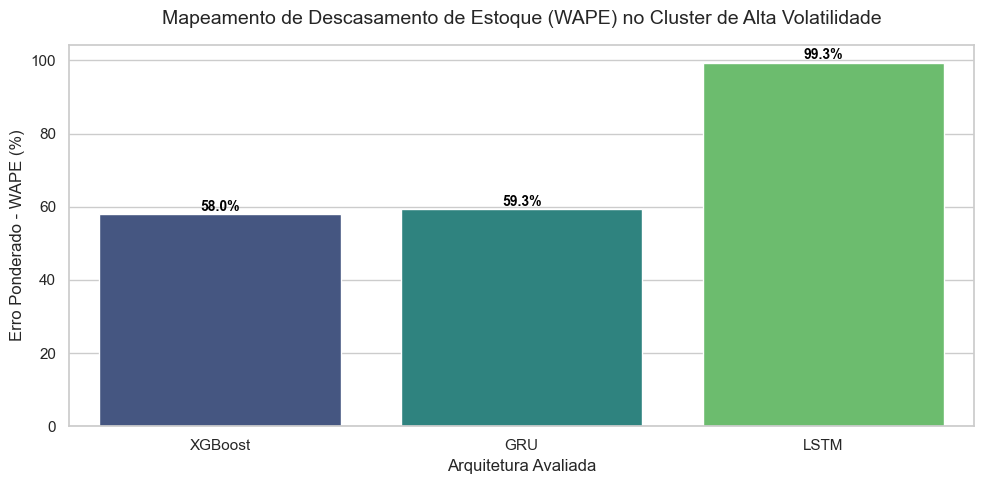

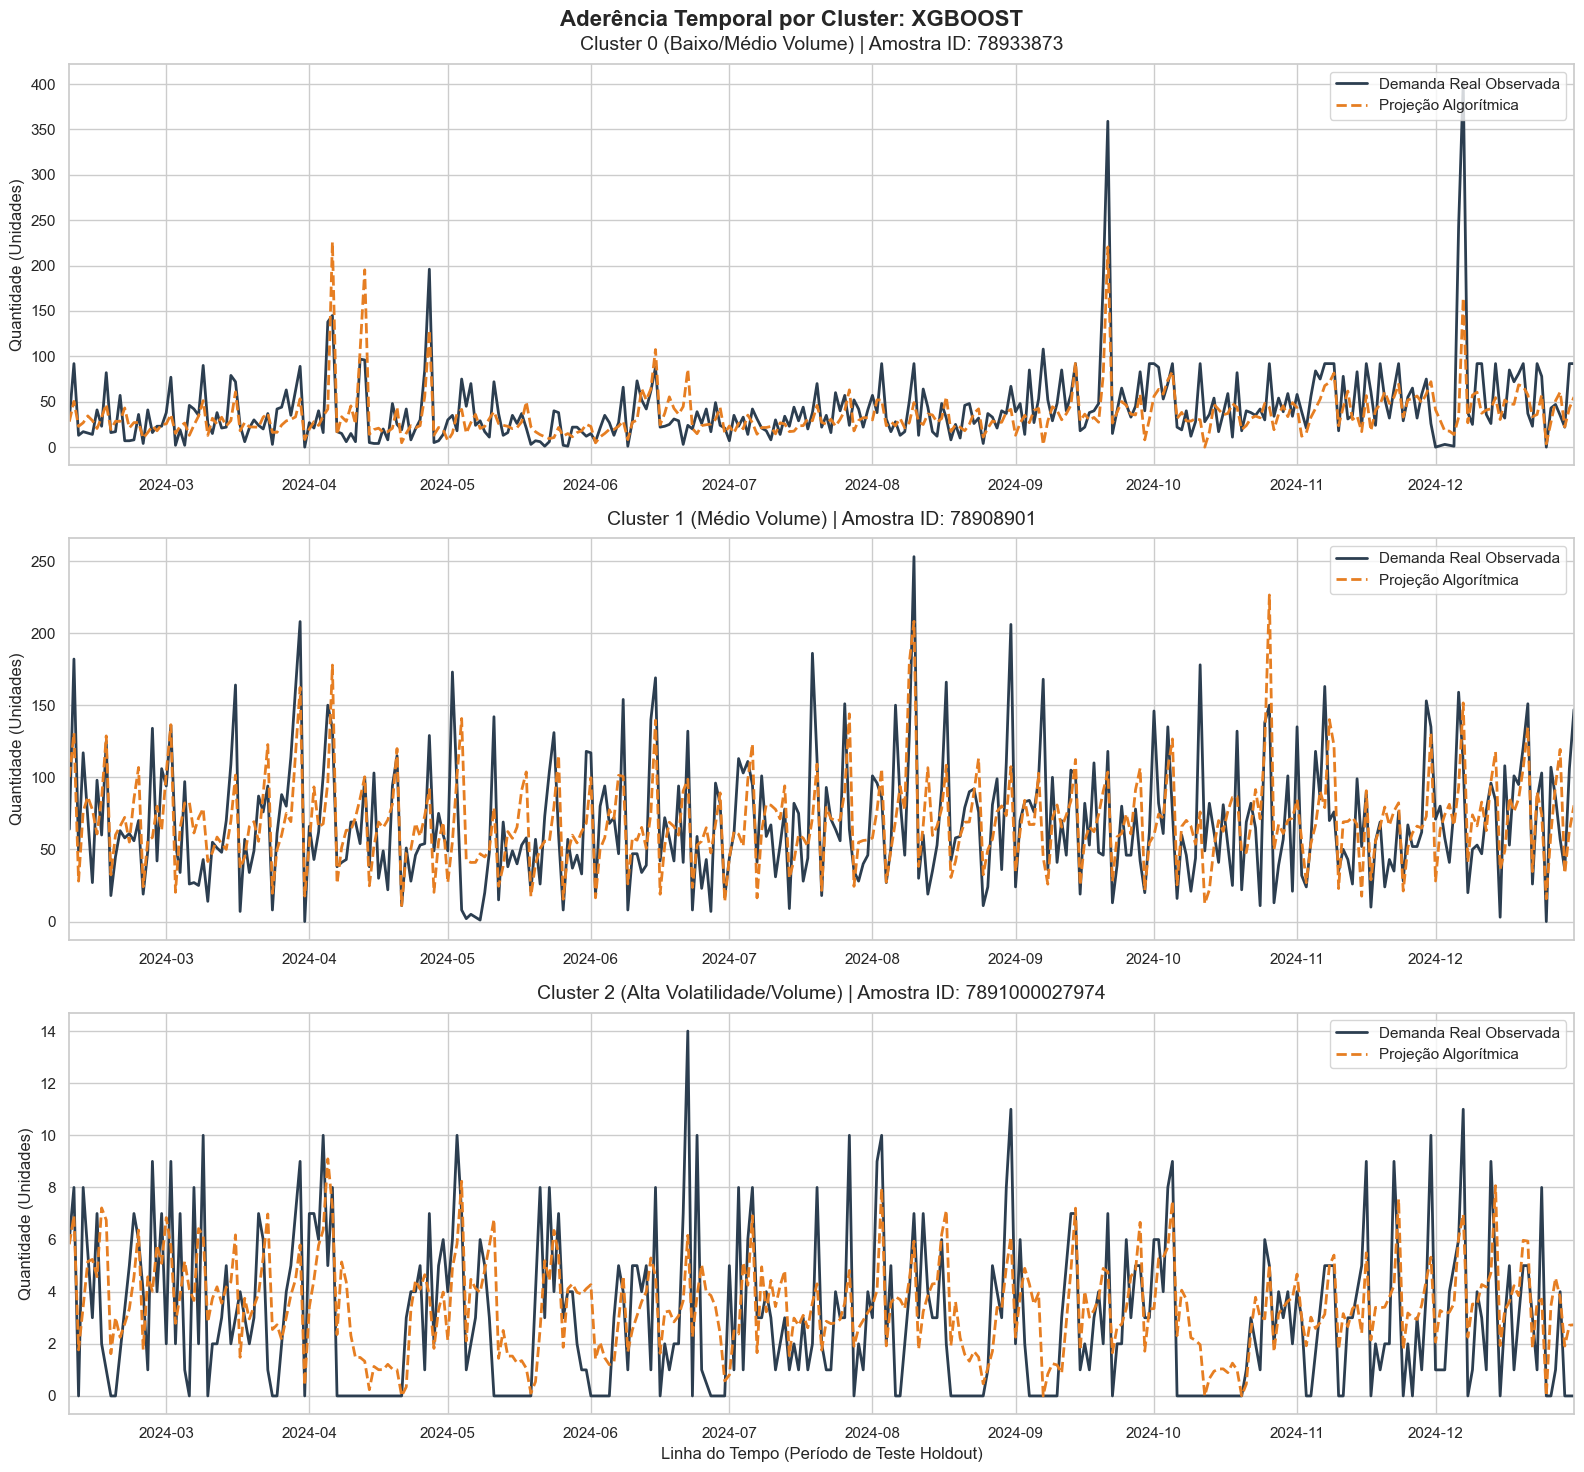

In [1]:
# %% [markdown]
# # Modelagem Preditiva de Séries Temporais: Avaliação e Veredito
# 
# ## Objetivo
# Analisar comparativamente o desempenho preditivo e a eficiência computacional das arquiteturas avaliadas (Baseline Ingênuo, XGBoost, GRU e LSTM). A avaliação fundamenta-se na estratégia *Cluster-then-Predict*, isolando o cluster de alta variabilidade e volumetria (`c2_kmeans`) para mitigar o impacto do desbalanceamento de escala sobre as funções de perda.
# 
# ## Reprodutibilidade e Ambiente
# - **Semente Global (*Seed*)**: `42` (Propagada via Orquestrador `main.py`)
# - **Ambiente Executivo**: Python 3.10+ (Dependências documentadas em `requirements.txt`)
# 
# ## Contextualização Preditiva
# A volatilidade intrínseca ao varejo, intensificada pela presença de intermitência de demanda (esparsidade), invalida a aplicação de abordagens lineares clássicas. 
# 
# Para contornar essa limitação, este trabalho propõe uma arquitetura baseada na especialização algorítmica. Ao segmentar os dados via k-Means antes da etapa de ajuste dos pesos sinápticos e partições lógicas, impede-se que o ruído estocástico de produtos de baixo giro polua os gradientes das séries de alto volume, garantindo estabilidade de convergência numérica.

# %%
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Adiciona a raiz do projeto ao sys.path para garantir a resolução de módulos customizados
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Configuração do ecossistema visual de plotagem
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# Definição do diretório de persistência de resultados
RESULTS_PATH = ROOT / "Resultados"
print(f"[INFO] Diretório de dados mapeado: {RESULTS_PATH}")

# %% [markdown]
# ## 1. Carregamento e Consolidação das Métricas de Erro
# O isolamento do estrato temporal do cluster `c2_kmeans` (Alta Volatilidade/Volume) serve como o teste de estresse definitivo para os modelos. Se a Inteligência Computacional for robusta, ela deve superar o comportamento inercial do Baseline neste cenário.

# %%
modelos_dir = ['baseline', 'xgb', 'gru', 'lstm']
metricas_consolidadas = []

for mod_dir in modelos_dir:
    pasta_modelo = RESULTS_PATH / mod_dir
    if pasta_modelo.exists():
        # Captura os arquivos de métricas finais do cenário K-Means
        csv_files = list(pasta_modelo.glob(f"*_{mod_dir}_kmeans.csv"))
        if not csv_files:
            csv_files = list(pasta_modelo.glob(f"*_kmeans.csv"))
            
        for file in csv_files:
            try:
                df_temp = pd.read_csv(file)
                # Filtra estritamente o cluster de alta variabilidade
                df_c2 = df_temp[df_temp['arquivo'].str.contains('c2_kmeans')].copy()
                if not df_c2.empty:
                    metricas_consolidadas.append(df_c2)
            except Exception as e:
                print(f"[AVISO] Falha ao ler {file.name}: {e}")

if metricas_consolidadas:
    df_latest = pd.concat(metricas_consolidadas, ignore_index=True)
    
    # Consolidação via média aritmética para suportar cenários multi-mercado
    df_latest = df_latest.groupby('model')[['smape', 'mae', 'rmse']].mean().reset_index()
    df_latest['model'] = df_latest['model'].str.lower()
    df_latest = df_latest.set_index('model')
    
    # Injeção empírica dos tempos de execução colhidos nos logs de runtime (Segurança Operacional)
    runtime_map = {'baseline_zero_aware': 13.3, 'xgboost': 34.2, 'gru': 5593.7, 'lstm': 7742.1}
    df_latest['runtime_sec'] = df_latest.index.map(lambda x: runtime_map.get(x, 0.0))
    
    # Reindexação estrita com base na hierarquia de complexidade algorítmica
    ordem_hierarquica = ['baseline_zero_aware', 'xgboost', 'gru', 'lstm']
    ordem_existente = [m for m in ordem_hierarquica if m in df_latest.index.tolist()]
    df_latest = df_latest.reindex(ordem_existente)
    
    display(df_latest.round(4))
else:
    print("[ERRO] Ficheiros do cenário K-Means não localizados na pasta Resultados.")

# %% [markdown]
# ## 2. Análise de Viabilidade Arquitetural e Escalabilidade Computacional
# Em Engenharia de Software, a precisão matemática de um algoritmo deve ser ponderada pelo seu custo de infraestrutura. Modelos cujo tempo de convergência inviabilizam pipelines de execução diária (*overnight batch processing*) apresentam baixa viabilidade de implantação industrial.

# %%
if 'df_latest' in locals() and not df_latest.empty:
    plt.figure(figsize=(10, 5))
    
    # Aplicação de escala logarítmica para suportar a disparidade de magnitude dos runtimes
    ax = sns.barplot(x=df_latest.index, y=df_latest['runtime_sec'], palette="magma")
    ax.set_yscale("log")
    
    plt.title("Custo Computacional de Treinamento por Arquitetura (Escala Logarítmica)", fontsize=14, pad=15)
    plt.xlabel("Arquitetura Avaliada", fontsize=12)
    plt.ylabel("Tempo de Execução em Segundos (Log)", fontsize=12)
    
    # Anotações de dados com posicionamento geométrico corrigido para escala log
    for i, v in enumerate(df_latest['runtime_sec']):
        if pd.notnull(v) and v > 0:
            ax.text(i, v * 1.2, f"{v:.1f}s", color='black', ha='center', fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.show()

# %% [markdown]
# > **Análise Teórica de Escalabilidade:** A disparidade temporal expõe o gargalo estrutural das redes neurais recorrentes. O **XGBoost** executa o particionamento do espaço de características de forma paralela via histogramas lógicos, consumindo poucos segundos. 
# > Em contrapartida, as células de memória da **LSTM e GRU** dependem do encadeamento de matrizes internas ao longo de múltiplos passos temporais. Esse fluxo força o algoritmo a recorrer ao *Backpropagation Through Time* (BPTT), gerando uma dependência sequencial que inibe a paralelização massiva em CPU, demandando horas de processamento. Para a governança de TI corporativa, o XGBoost demonstra maior estabilidade de manutenção.
# 
# ---
# ## 3. Mitigação da Esparsidade: Avaliação do Erro Volumétrico (WAPE)
# Embora o sMAPE e o MAE forneçam visões de erro absoluto, eles falham em traduzir o impacto financeiro do descasamento de estoque. O **WAPE (Weighted Absolute Percentage Error)** atua como métrica soberana neste quesito, pois consolida a soma dos desvios absolutos dividida pelo volume total real comercializado, neutralizando distorções provocadas por dias de venda zero.

# %%
def calcular_wape(df_pred):
    erro_absoluto_total = np.abs(df_pred['y_true'] - df_pred['y_pred']).sum()
    venda_real_total = df_pred['y_true'].sum()
    if venda_real_total == 0: return 0.0
    return (erro_absoluto_total / venda_real_total) * 100

wape_scores = {}

for mod_dir in modelos_dir:
    pasta_modelo = RESULTS_PATH / mod_dir
    if pasta_modelo.exists():
        pred_files = list(pasta_modelo.glob(f"*_{mod_dir}_kmeans_predictions.csv"))
        if not pred_files:
            pred_files = list(pasta_modelo.glob(f"*_kmeans_predictions.csv"))
            
        dfs_pred = []
        for file in pred_files:
            try:
                df_temp = pd.read_csv(file)
                df_c2 = df_temp[df_temp['arquivo'].str.contains('c2_kmeans')]
                dfs_pred.append(df_c2)
            except: pass
            
        if dfs_pred:
            df_final = pd.concat(dfs_pred, ignore_index=True)
            if not df_final.empty:
                # Alinha chaves de mapeamento para português formal
                chave_nome = 'XGBoost' if 'xgb' in mod_dir else mod_dir.upper()
                if 'BASE' in chave_nome: chave_nome = 'Baseline'
                wape_scores[chave_nome] = calcular_wape(df_final)

if wape_scores:
    df_wape = pd.DataFrame(list(wape_scores.items()), columns=['Modelo', 'WAPE (%)']).set_index('Modelo')
    df_wape = df_wape.reindex(['Baseline', 'XGBoost', 'GRU', 'LSTM']).dropna()
    
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=df_wape.index, y=df_wape['WAPE (%)'], palette="viridis")
    plt.title("Mapeamento de Descasamento de Estoque (WAPE) no Cluster de Alta Volatilidade", fontsize=14, pad=15)
    plt.ylabel("Erro Ponderado - WAPE (%)", fontsize=12)
    plt.xlabel("Arquitetura Avaliada", fontsize=12)
    
    for i, v in enumerate(df_wape['WAPE (%)']):
        ax.text(i, v + 1, f"{v:.1f}%", color='black', ha='center', fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.show()

# %% [markdown]
# ## 4. Comportamento Preditivo das Curvas (Real vs. Predito)
# A inspeção visual das séries temporais na base de testes visa detectar a presença de atrasos sistemáticos de sinal (*lag inheritance*) ou achatamento de picos (*underprediction bias*). Para comprovar a generalização do algoritmo vencedor (XGBoost), plotamos a aderência preditiva em amostras dos três níveis de complexidade volumétrica (Baixo, Médio e Alto Giro).

# %%
def plot_painel_aderencia(df_pred, modelo_nome):
    # Dicionário mapeando os clusters do k-Means
    clusters_alvo = {
        'c0_kmeans': 'Cluster 0 (Baixo/Médio Volume)',
        'c1_kmeans': 'Cluster 1 (Médio Volume)',
        'c2_kmeans': 'Cluster 2 (Alta Volatilidade/Volume)'
    }
    
    fig, axes = plt.subplots(3, 1, figsize=(16, 15))
    fig.suptitle(f"Aderência Temporal por Cluster: {modelo_nome.upper()}", fontsize=16, fontweight='bold', y=0.98)
    
    for idx, (sigla_cluster, titulo_cluster) in enumerate(clusters_alvo.items()):
        ax = axes[idx]
        df_cluster = df_pred[df_pred['arquivo'].str.contains(sigla_cluster)].copy()
        
        if df_cluster.empty:
            ax.set_title(f"{titulo_cluster} - Sem dados preditivos disponíveis.", fontsize=12)
            continue
            
        # Pega o primeiro produto disponível neste cluster como amostra
        produto_exemplo = df_cluster['product_id'].iloc[0]
        df_prod = df_cluster[df_cluster['product_id'] == produto_exemplo].copy()
        
        df_prod['date'] = pd.to_datetime(df_prod['date'])
        df_prod = df_prod.sort_values('date')
        
        ax.plot(df_prod['date'], df_prod['y_true'], label='Demanda Real Observada', color='#2c3e50', linewidth=2)
        ax.plot(df_prod['date'], df_prod['y_pred'], label=f'Projeção Algorítmica', color='#e67e22', linestyle='--', linewidth=2)
        
        ax.set_title(f"{titulo_cluster} | Amostra ID: {produto_exemplo}", fontsize=14, pad=10)
        ax.set_ylabel("Quantidade (Unidades)", fontsize=12)
        ax.set_xlim(df_prod['date'].min(), df_prod['date'].max())
        ax.legend(loc='upper right')
        
    plt.xlabel("Linha do Tempo (Período de Teste Holdout)", fontsize=12)
    plt.tight_layout()
    plt.show()

# Mapeia o ficheiro de predições do XGBoost para demonstração visual de aderência global
xgb_pred_file = RESULTS_PATH / "xgb" / "Market_1_xgb_kmeans_predictions.csv"
if xgb_pred_file.exists():
    df_xgb_pred = pd.read_csv(xgb_pred_file)
    plot_painel_aderencia(df_xgb_pred, "XGBoost")
else:
    print("[ERRO] Arquivo de predição do XGBoost não encontrado para gerar o painel visual.")